# 01 — Data Exploration
Explore a SOLEY batch output: schema, fault distribution,
weather patterns, and the engineered features used by ML models.


## 1. Imports & setup

In [1]:
import sys, pathlib

# Ensure both repo root and its parent are importable, regardless of where
# the notebook kernel starts.
cwd = pathlib.Path.cwd()
sys.path.insert(0, str(cwd))
sys.path.insert(0, str(cwd.parent))

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from library.utils import setup_logging
from library.config import BatchConfig
from library.data.loader import load_split
from library.data import prepare_file_registry
from library.features import add_features

setup_logging()
%matplotlib inline
plt.rcParams["figure.dpi"] = 120


## 2. Point to your data
Set `DATA_DIR` to the folder that contains your SOLEY parquet files
(and optionally `batch_config.json`).


In [2]:
DATA_DIR   = "data"
OUTPUT_DIR = "outputs/exploration"
import pathlib
pathlib.Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)


## 3. Auto-detect configuration

In [3]:
cfg = BatchConfig(DATA_DIR)
print(cfg)
print()
print(f"Array capacity : {cfg.array_kwp:.2f} kWp")
print(f"Locations      : {len(cfg.locations)}")
print(f"SCADA features : {len(cfg.scada_features)}")
print(f"Device features: {len(cfg.device_features)}")
print(f"Stress features: {len(cfg.stress_features)}")
print(f"Total features : {len(cfg.all_feature_cols)}")


  No batch_config.json — using auto-detection.
  Estimated array capacity: 5.89 kWp (from max DC power)
  God-mode columns found in data and excluded from all feature sets: ['detailed_balance_efficiency_pct', 'ff', 'jmpp_a_m2', 'jsc_a_m2', 'vmpp_v', 'voc_v']
  Columns: 11 SCADA, 8 device physics, 6 stress, 29 constant (excluded), 6 god-mode (excluded), 25 total features
BatchConfig(array_kwp=5.89, locations=0, features=25)

Array capacity : 5.89 kWp
Locations      : 0
SCADA features : 11
Device features: 8
Stress features: 6
Total features : 25


## 4. Load a sample of data (no subsampling limit)

In [4]:
# Build a temporary registry for exploration — no split assignment
# needed since we're just sampling the data, not training.
# Using prepare_file_registry + load_split ensures the same
# preprocessing (daytime filter, feature engineering) as training.
registry_explore = prepare_file_registry(DATA_DIR, cfg)
df_explore = load_split(registry_explore, cfg, max_rows=200_000)
df_explore["timestamp"] = pd.to_datetime(df_explore["timestamp"])
print(df_explore.shape)
df_explore.head(3)


Registry: 24 files, 7 fault types
After daytime filter: 306,529 rows
After daytime filter: 306,678 rows
After daytime filter: 306,917 rows
After daytime filter: 307,835 rows
After daytime filter: 307,790 rows
After daytime filter: 307,987 rows
After daytime filter: 307,438 rows
After daytime filter: 307,415 rows
After daytime filter: 307,489 rows
After daytime filter: 306,832 rows
After daytime filter: 307,080 rows
After daytime filter: 307,175 rows
After daytime filter: 302,072 rows
After daytime filter: 302,957 rows
After daytime filter: 302,776 rows
After daytime filter: 299,811 rows
After daytime filter: 299,039 rows
After daytime filter: 298,908 rows
After daytime filter: 306,828 rows
After daytime filter: 306,687 rows
After daytime filter: 306,846 rows
After daytime filter: 306,809 rows
After daytime filter: 306,751 rows
After daytime filter: 306,642 rows
  load_split: 7,333,291 rows from 24 entries
  Stratified subsample (by fault_type) → 200,000 rows
(200000, 52)


,ac_power_kw,aging_factor,ambient_temp_c,aoi_correction_factor,aoi_deg,azimuth_deg,cell_temp_c,dc_ac_ratio,dc_power_kw,dhi_wm2,...,timestamp,wind_speed_ms,hour_sin,hour_cos,doy_sin,doy_cos,performance_ratio,pr_deviation,dc_ac_power_ratio,power_step
0,1.626872,0.991438,31.748810,0.991252,46.157127,180.0,37.285606,1.1,1.700801,315.545715,...,2019-09-17 20:25:00,4.8,-0.806445,0.591310,-0.972118,-0.234491,0.783041,0.980011,1.045442,0.031182
1,1.206816,0.980932,10.136439,0.996398,40.697403,180.0,24.886543,1.4,1.256907,202.550217,...,2021-10-23 17:45:00,0.0,-0.997859,-0.065403,-0.927542,0.373720,0.781000,1.113054,1.041507,0.313171
2,3.331114,0.972822,24.112606,0.996328,40.782963,180.0,65.010208,1.4,3.479662,100.913429,...,2023-06-07 23:00:00,0.0,-0.258819,0.965926,0.409356,-0.912375,0.729612,1.010695,1.044594,0.041073


## 5. Schema & dtypes

In [5]:
df_explore.dtypes.to_frame("dtype")


,dtype
ac_power_kw,float32
aging_factor,float32
ambient_temp_c,float32
aoi_correction_factor,float32
aoi_deg,float32
azimuth_deg,float32
cell_temp_c,float32
dc_ac_ratio,float32
dc_power_kw,float32
dhi_wm2,float32


## 6. Fault distribution

In [6]:
print("fault_active counts")
print(df_explore["fault_active"].value_counts())
print()
print("fault_type counts (faulted rows only)")
faulted = df_explore[df_explore["fault_active"]]
vc = faulted["fault_type"].value_counts()
print(vc)


fault_active counts
fault_active
False    165918
True      34082
Name: count, dtype: int64

fault_type counts (faulted rows only)
fault_type
pid               8368
solder_fatigue    7409
cell_crack        6887
string_failure    5065
mppt_failure      4982
sudden_soiling    1371
Name: count, dtype: int64


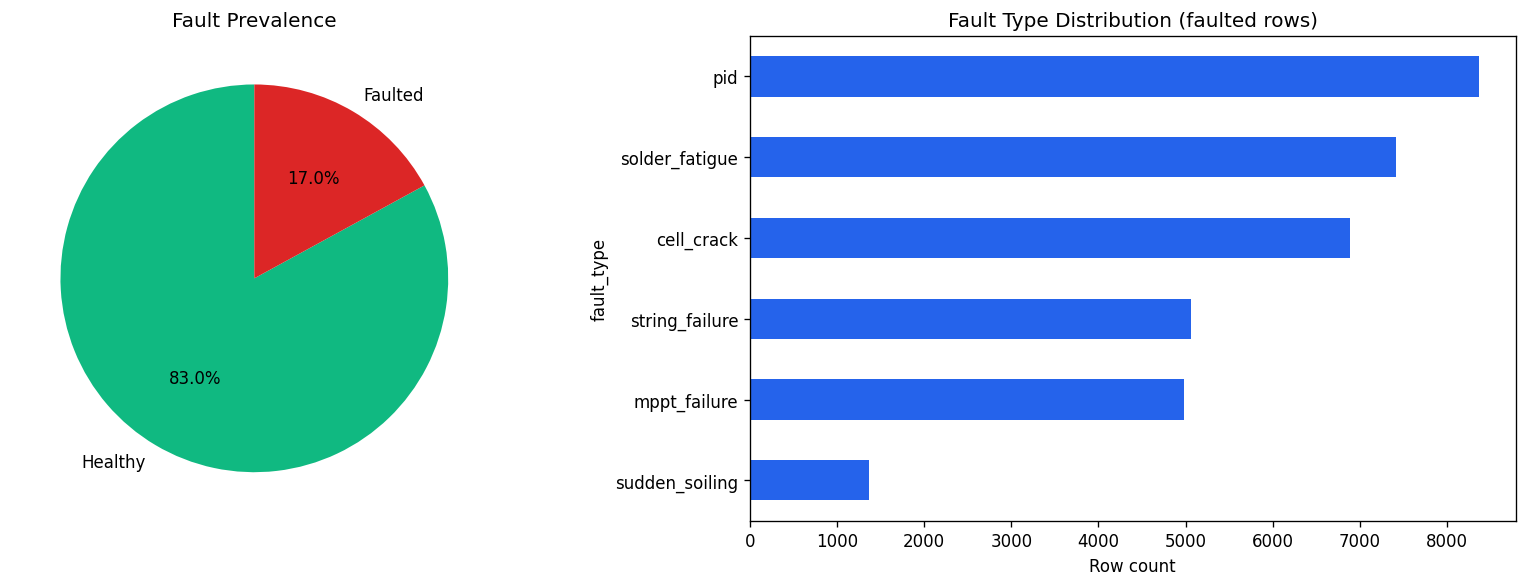

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fault prevalence
ax = axes[0]
labels = ["Healthy", "Faulted"]
sizes  = [len(df_explore) - len(faulted), len(faulted)]
ax.pie(sizes, labels=labels, autopct="%1.1f%%",
       colors=["#10b981", "#dc2626"], startangle=90)
ax.set_title("Fault Prevalence")

# Fault type breakdown
ax = axes[1]
vc.plot(kind="barh", ax=ax, color="#2563eb")
ax.set_xlabel("Row count")
ax.set_title("Fault Type Distribution (faulted rows)")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fault_distribution.png", bbox_inches="tight")
plt.show()


## 7. Temporal overview

In [8]:
if "sim_year" in df_explore.columns:
    year_counts = df_explore.groupby("sim_year")["fault_active"].agg(["sum", "count"])
    year_counts["fault_rate"] = year_counts["sum"] / year_counts["count"]
    display(year_counts)


,sum,count,fault_rate
sim_year,,,
1,2183,33480,0.065203
2,5095,33499,0.152094
3,5932,33497,0.177090
4,6527,33248,0.196313
5,7139,33503,0.213085
6,7206,32773,0.219876


## 8. Apply feature engineering & inspect new features

In [9]:
df = add_features(df_explore.copy(), cfg.array_kwp)
new_cols = ["hour_sin", "hour_cos", "doy_sin", "doy_cos",
            "performance_ratio", "pr_deviation",
            "dc_ac_power_ratio", "power_step"]
df[new_cols].describe().round(4)


After daytime filter: 200,000 rows


,hour_sin,hour_cos,doy_sin,doy_cos,performance_ratio,pr_deviation,dc_ac_power_ratio,power_step
count,200000.0000,200000.0000,200000.0000,200000.0000,200000.0000,200000.0000,200000.0000,200000.0000
mean,-0.6024,0.1007,0.0127,-0.0896,0.6887,1.0000,1.1293,0.3579
std,0.3834,0.6928,0.7078,0.7006,0.1283,0.1840,0.3143,0.1379
min,-1.0000,-1.0000,-1.0000,-1.0000,0.0000,0.0000,0.9849,0.0000
25%,-0.9239,-0.5556,-0.6933,-0.7776,0.6431,0.9294,1.0419,0.2563
50%,-0.7224,0.1736,0.0258,-0.1671,0.7250,1.0421,1.0562,0.3392
75%,-0.3624,0.7934,0.7236,0.5982,0.7786,1.1189,1.0887,0.4441
max,0.8434,1.0000,1.0000,1.0000,0.9426,1.6494,5.0000,0.8227


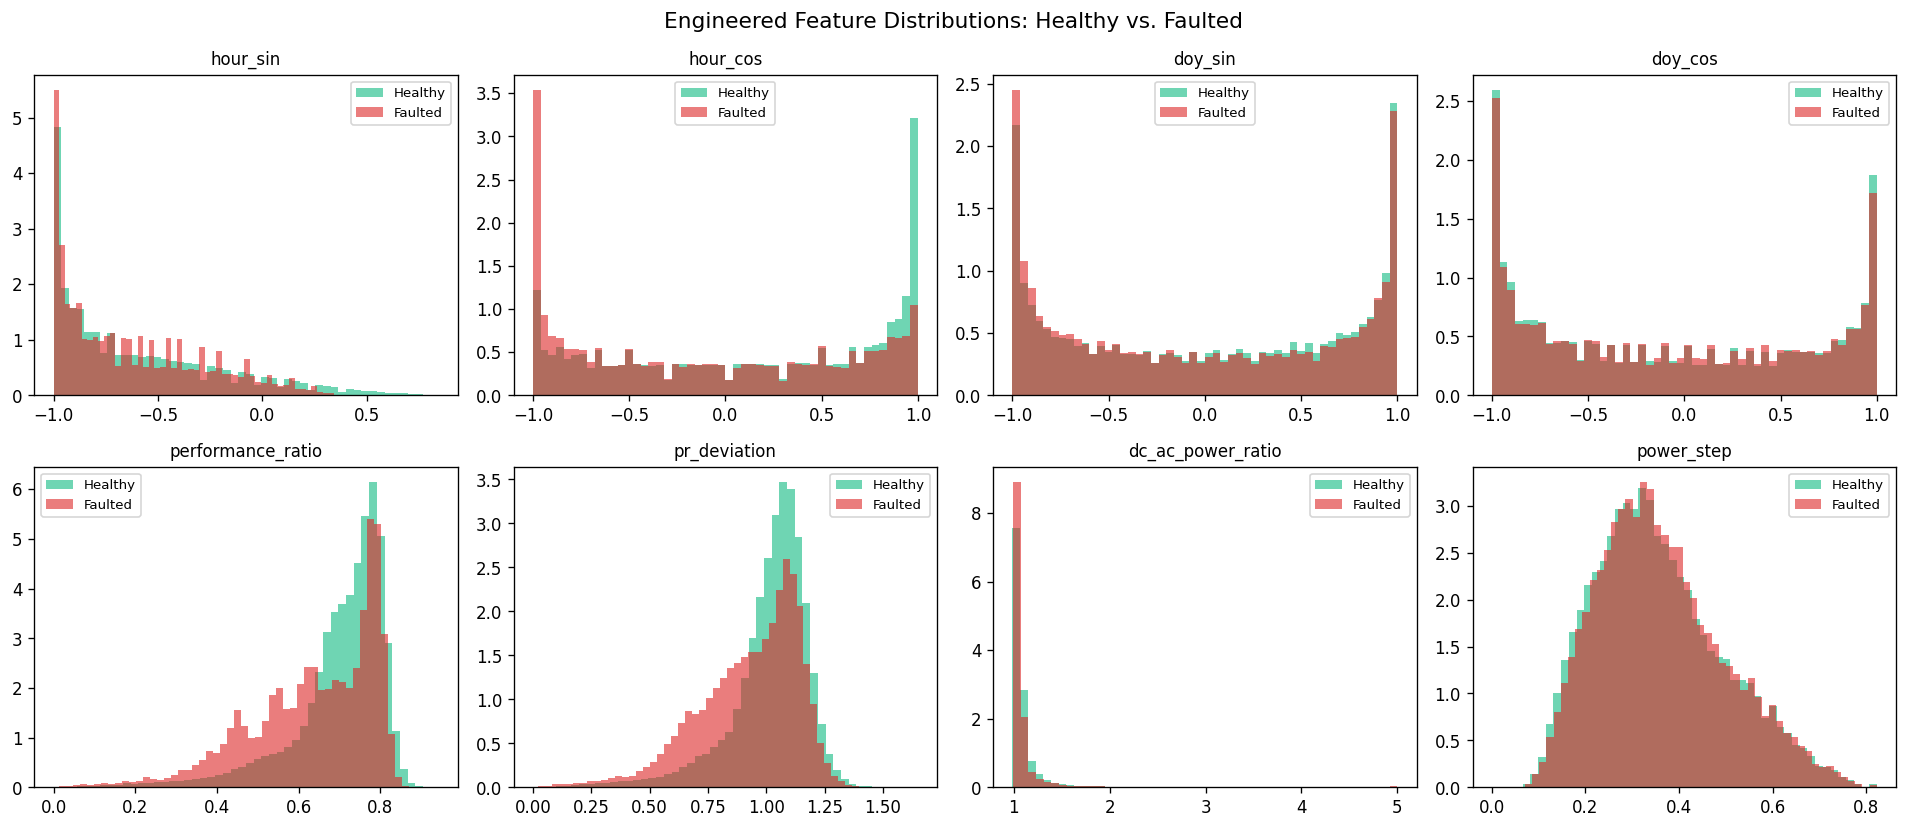

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for ax, col in zip(axes, new_cols):
    healthy = df[~df["fault_active"]][col].dropna()
    bad     = df[ df["fault_active"]][col].dropna()
    ax.hist(healthy, bins=50, alpha=0.6, label="Healthy", color="#10b981",
            density=True)
    ax.hist(bad,     bins=50, alpha=0.6, label="Faulted", color="#dc2626",
            density=True)
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=8)
plt.suptitle("Engineered Feature Distributions: Healthy vs. Faulted",
             fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/feature_distributions.png", bbox_inches="tight")
plt.show()


## 9. Correlation heatmap (SCADA features)

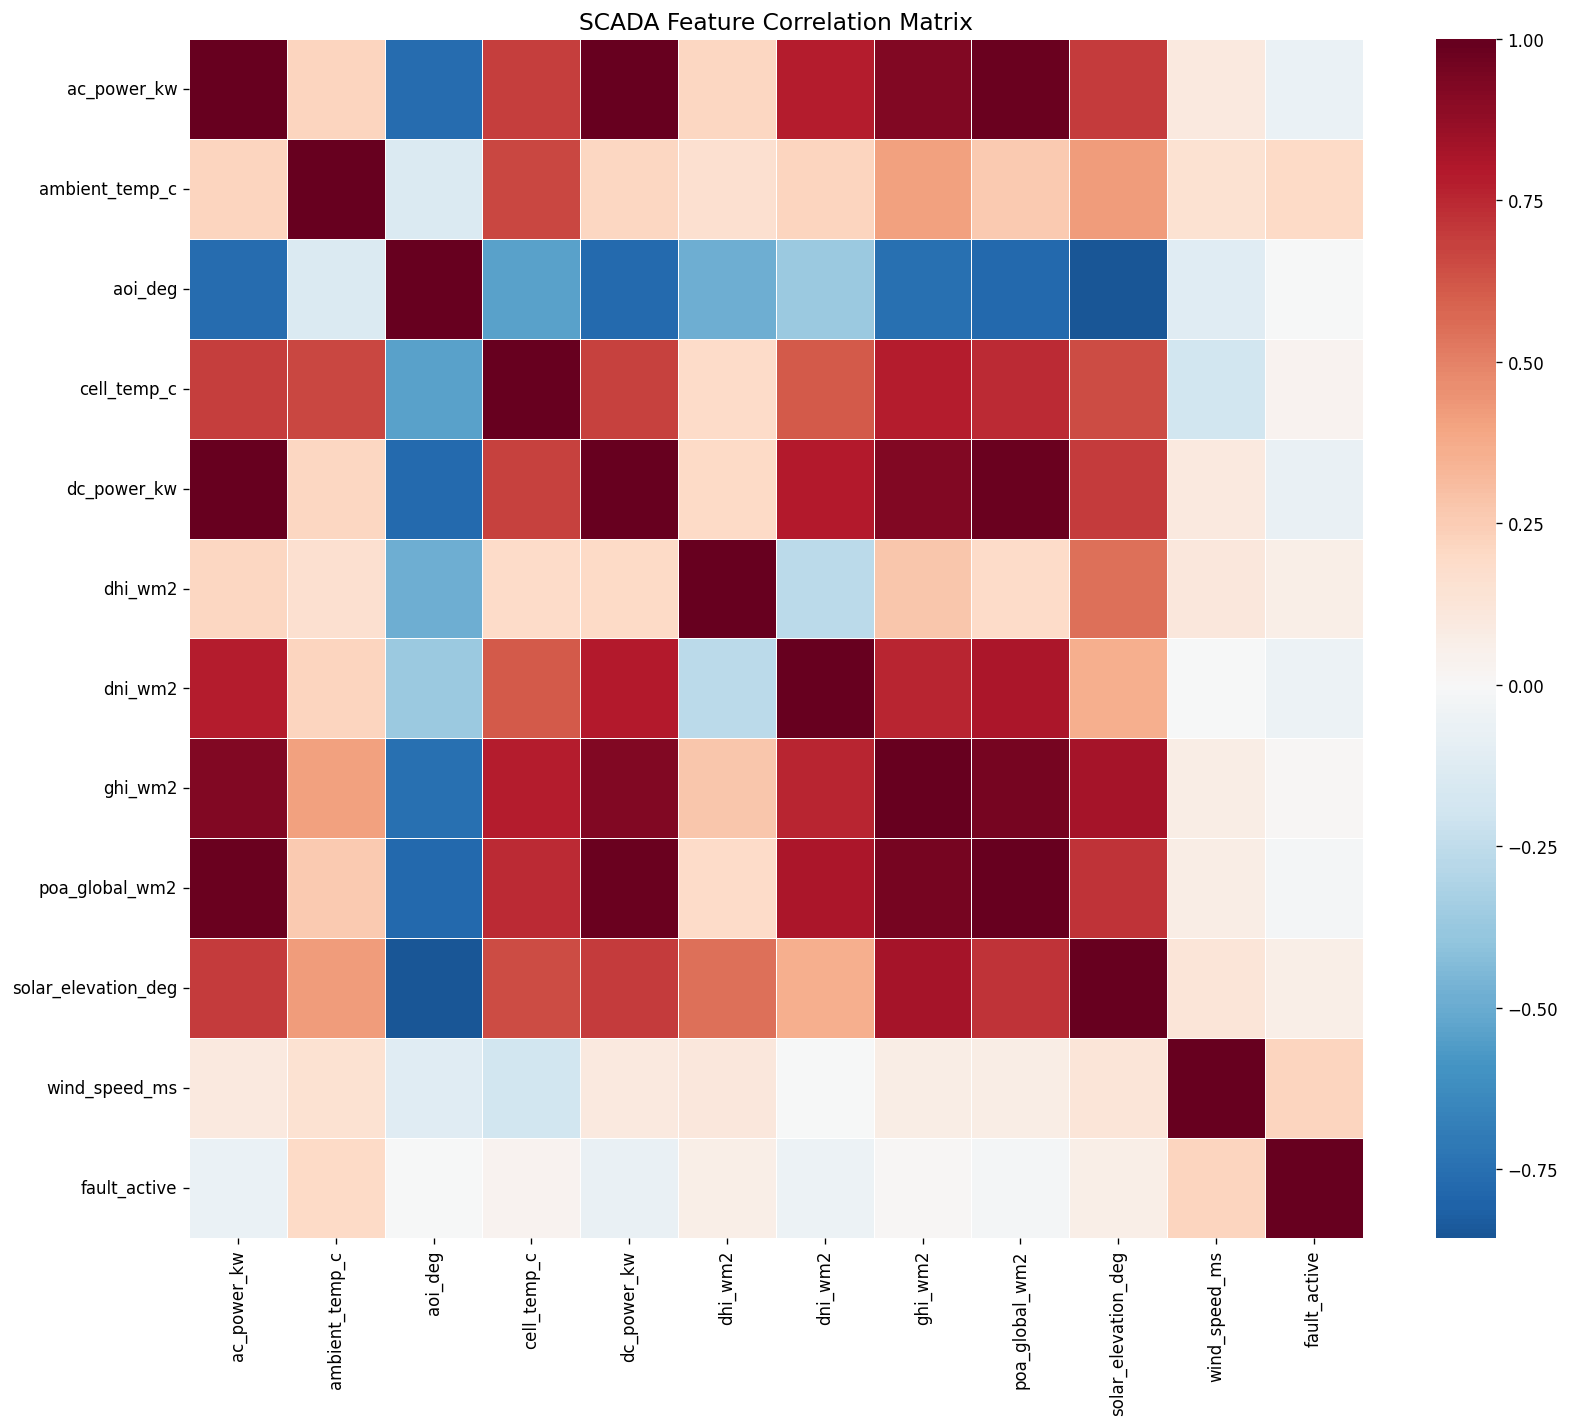

In [11]:
import seaborn as sns

scada_cols = [c for c in cfg.scada_features if c in df.columns]
corr = df[scada_cols + ["fault_active"]].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, annot=False, cmap="RdBu_r", center=0,
            linewidths=0.3, ax=ax)
ax.set_title("SCADA Feature Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/correlation_heatmap.png", bbox_inches="tight")
plt.show()


## 10. Sample time-series: one run

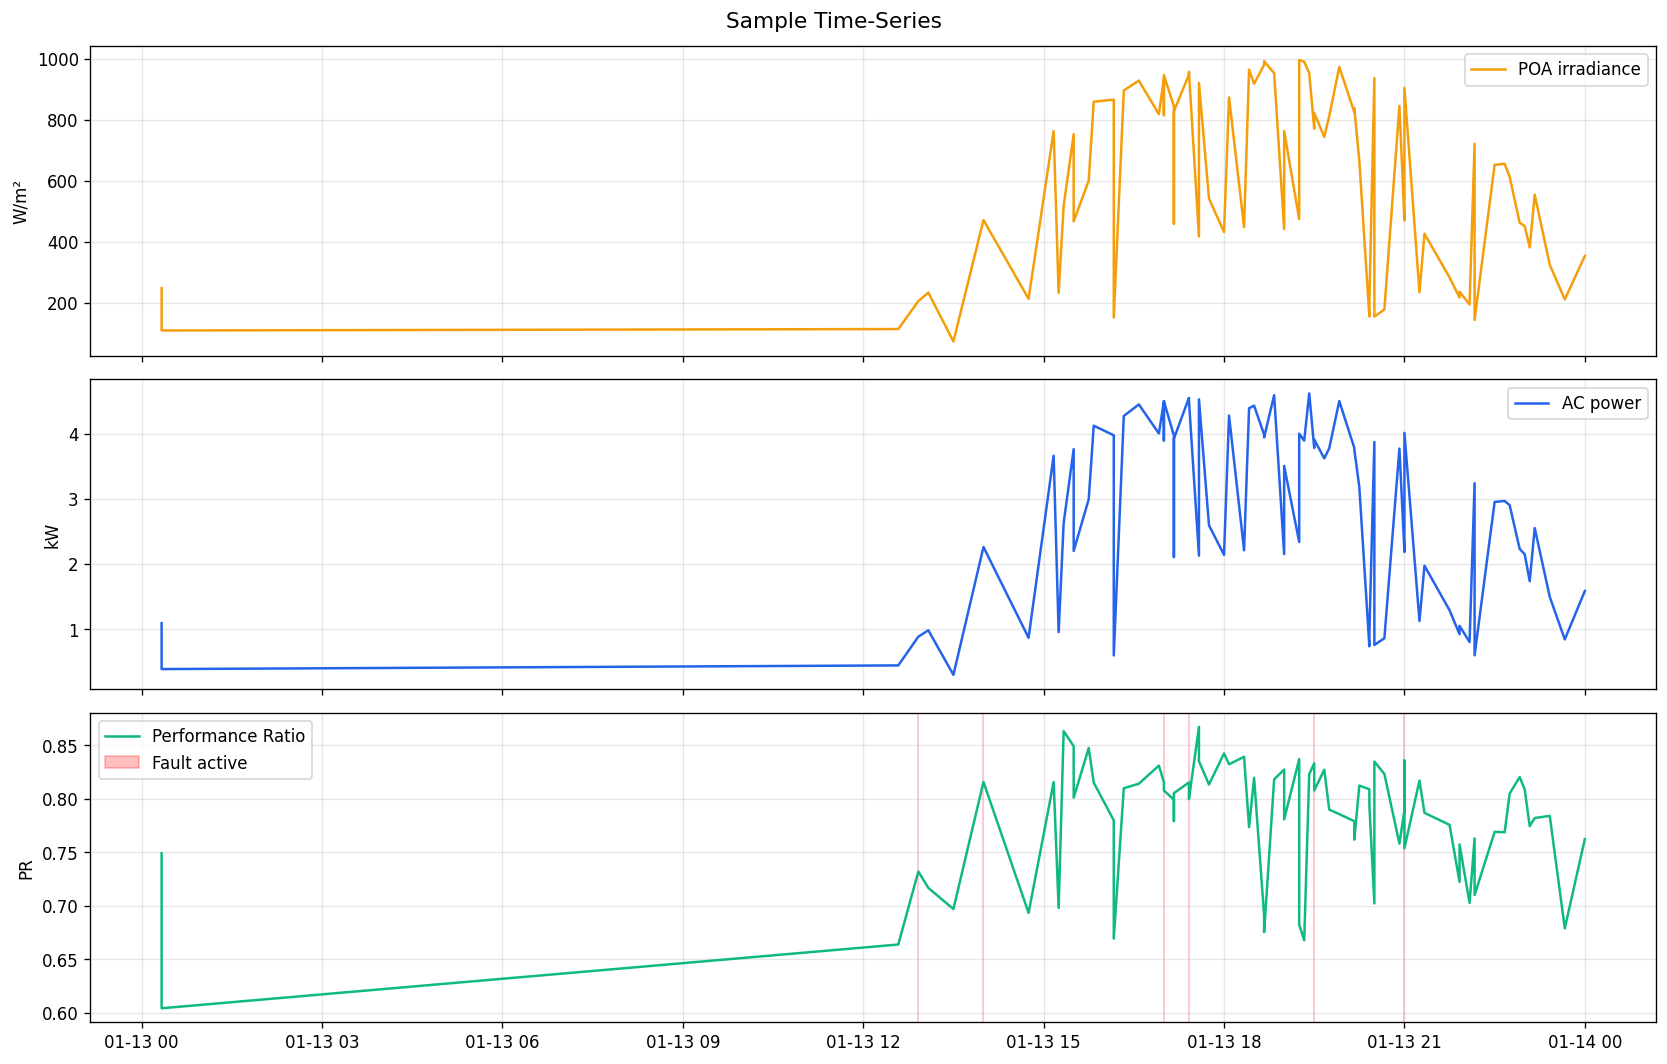

In [12]:
if "sim_day" in df.columns:
    # Pick one day from one run
    sample = df[df["sim_day"] == df["sim_day"].iloc[100]].copy()
    sample = sample.sort_values("timestamp")

    fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
    axes[0].plot(sample["timestamp"], sample["poa_global_wm2"],
                 color="#f59e0b", label="POA irradiance")
    axes[0].set_ylabel("W/m²"); axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(sample["timestamp"], sample["ac_power_kw"],
                 color="#2563eb", label="AC power")
    axes[1].set_ylabel("kW"); axes[1].legend(); axes[1].grid(alpha=0.3)

    axes[2].plot(sample["timestamp"], sample["performance_ratio"],
                 color="#10b981", label="Performance Ratio")
    # Shade faulted periods
    if sample["fault_active"].any():
        fa = sample["fault_active"].values
        ts = sample["timestamp"].values
        axes[2].fill_between(ts, 0, 1,
                             where=fa, alpha=0.25, color="red",
                             label="Fault active", transform=axes[2].get_xaxis_transform())
    axes[2].set_ylabel("PR"); axes[2].legend(); axes[2].grid(alpha=0.3)

    fig.suptitle("Sample Time-Series", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/sample_timeseries.png", bbox_inches="tight")
    plt.show()
else:
    print("sim_day column not present — skipping time-series plot.")
